In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [26]:
data = {
    "Stadium": [
        "MetLife Stadium", "AT&T Stadium", "Mercedes-Benz Stadium",
        "SoFi Stadium", "Lincoln Financial Field", "Levi's Stadium",
        "Lumen Field", "Hard Rock Stadium", "NRG Stadium",
        "Arrowhead Stadium", "Gillette Stadium", "Estadio Azteca",
        "Estadio BBVA", "Estadio Akron", "BC Place", "BMO Field"
    ],
    "City": [
        "New York", "Dallas", "Atlanta", "Los Angeles", "Philadelphia",
        "San Francisco Bay Area", "Seattle", "Miami", "Houston",
        "Kansas City", "Boston", "Mexico City", "Monterrey",
        "Guadalajara", "Vancouver", "Toronto"
    ],
    "Country": [
        "USA", "USA", "USA", "USA", "USA", "USA", "USA", "USA",
        "USA", "USA", "USA", "Mexico", "Mexico", "Mexico",
        "Canada", "Canada"
    ],
    "Capacity": [
        82500, 80000, 71000, 70000, 67500, 68500, 69000, 65000,
        72000, 76000, 65000, 83000, 53500, 49800, 54500, 45700
    ],
    "Annual_Tourists_Millions": [
        62, 27, 57, 50, 43, 25, 40, 28,
        23, 27, 22, 15, 3, 5, 11, 9
    ],
    "Airport_Passengers_Millions": [
        140, 81, 108, 88, 31, 58, 52, 56,
        61, 12, 43, 50, 13, 18, 26, 50
    ],
    "Hotel_Rooms": [
        120000, 95000, 95000, 110000, 45000, 60000, 40000, 65000,
        80000, 35000, 40000, 60000, 20000, 25000, 25000, 45000
    ],
    "Metro_Population_Millions": [
        20.1, 7.8, 6.2, 13.0, 6.2, 7.7, 4.0, 6.1,
        7.3, 2.4, 4.9, 22.0, 5.3, 5.2, 2.7, 6.7
    ]
}

df = pd.DataFrame(data)
df

,Stadium,City,Country,Capacity,Annual_Tourists_Millions,Airport_Passengers_Millions,Hotel_Rooms,Metro_Population_Millions
0,MetLife Stadium,New York,USA,82500,62,140,120000,20.1
1,AT&T Stadium,Dallas,USA,80000,27,81,95000,7.8
2,Mercedes-Benz Stadium,Atlanta,USA,71000,57,108,95000,6.2
3,SoFi Stadium,Los Angeles,USA,70000,50,88,110000,13.0
4,Lincoln Financial Field,Philadelphia,USA,67500,43,31,45000,6.2
5,Levi's Stadium,San Francisco Bay Area,USA,68500,25,58,60000,7.7
6,Lumen Field,Seattle,USA,69000,40,52,40000,4.0
7,Hard Rock Stadium,Miami,USA,65000,28,56,65000,6.1
8,NRG Stadium,Houston,USA,72000,23,61,80000,7.3
9,Arrowhead Stadium,Kansas City,USA,76000,27,12,35000,2.4


In [27]:
df.head()

,Stadium,City,Country,Capacity,Annual_Tourists_Millions,Airport_Passengers_Millions,Hotel_Rooms,Metro_Population_Millions
0,MetLife Stadium,New York,USA,82500,62,140,120000,20.1
1,AT&T Stadium,Dallas,USA,80000,27,81,95000,7.8
2,Mercedes-Benz Stadium,Atlanta,USA,71000,57,108,95000,6.2
3,SoFi Stadium,Los Angeles,USA,70000,50,88,110000,13.0
4,Lincoln Financial Field,Philadelphia,USA,67500,43,31,45000,6.2


In [28]:
df.tail()

,Stadium,City,Country,Capacity,Annual_Tourists_Millions,Airport_Passengers_Millions,Hotel_Rooms,Metro_Population_Millions
11,Estadio Azteca,Mexico City,Mexico,83000,15,50,60000,22.0
12,Estadio BBVA,Monterrey,Mexico,53500,3,13,20000,5.3
13,Estadio Akron,Guadalajara,Mexico,49800,5,18,25000,5.2
14,BC Place,Vancouver,Canada,54500,11,26,25000,2.7
15,BMO Field,Toronto,Canada,45700,9,50,45000,6.7


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Stadium                      16 non-null     object 
 1   City                         16 non-null     object 
 2   Country                      16 non-null     object 
 3   Capacity                     16 non-null     int64  
 4   Annual_Tourists_Millions     16 non-null     int64  
 5   Airport_Passengers_Millions  16 non-null     int64  
 6   Hotel_Rooms                  16 non-null     int64  
 7   Metro_Population_Millions    16 non-null     float64
dtypes: float64(1), int64(4), object(3)
memory usage: 1.1+ KB


In [30]:
df.columns

Index(['Stadium', 'City', 'Country', 'Capacity', 'Annual_Tourists_Millions',
       'Airport_Passengers_Millions', 'Hotel_Rooms',
       'Metro_Population_Millions'],
      dtype='object')

In [31]:
from sklearn.preprocessing import MinMaxScaler

cols = [
    'Annual_Tourists_Millions',
    'Airport_Passengers_Millions',
    'Hotel_Rooms'
]

scaler = MinMaxScaler()

scaled = pd.DataFrame(
    scaler.fit_transform(df[cols]),
    columns=cols
)

df['Infrastructure_Index'] = (
      0.4 * scaled['Annual_Tourists_Millions']
    + 0.3 * scaled['Airport_Passengers_Millions']
    + 0.3 * scaled['Hotel_Rooms']
)

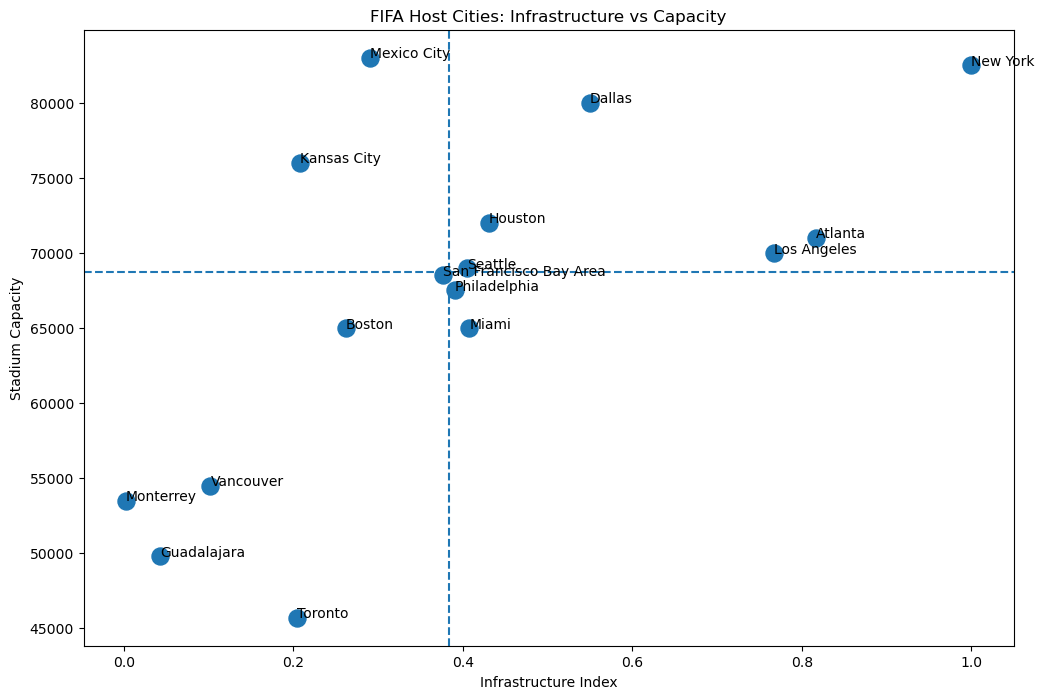

In [32]:
import matplotlib.pyplot as plt

x_mid = df['Infrastructure_Index'].median()
y_mid = df['Capacity'].median()

plt.figure(figsize=(12,8))

plt.scatter(
    df['Infrastructure_Index'],
    df['Capacity'],
    s=150
)

for _, row in df.iterrows():
    plt.annotate(
        row['City'],
        (
            row['Infrastructure_Index'],
            row['Capacity']
        )
    )

# Quadrant lines
plt.axvline(x=x_mid, linestyle='--')
plt.axhline(y=y_mid, linestyle='--')

plt.xlabel('Infrastructure Index')
plt.ylabel('Stadium Capacity')

plt.title(
    'FIFA Host Cities: Infrastructure vs Capacity'
)

plt.show()

In [33]:
coords = {
    'New York': (40.7128, -74.0060),
    'Dallas': (32.7767, -96.7970),
    'Atlanta': (33.7490, -84.3880),
    'Los Angeles': (34.0522, -118.2437),
    'Philadelphia': (39.9526, -75.1652),
    'San Francisco Bay Area': (37.3875, -121.9724),
    'Seattle': (47.6062, -122.3321),
    'Miami': (25.7617, -80.1918),
    'Houston': (29.7604, -95.3698),
    'Kansas City': (39.0997, -94.5786),
    'Boston': (42.3601, -71.0589),
    'Mexico City': (19.4326, -99.1332),
    'Monterrey': (25.6866, -100.3161),
    'Guadalajara': (20.6597, -103.3496),
    'Vancouver': (49.2827, -123.1207),
    'Toronto': (43.6532, -79.3832)
}

df['Latitude'] = df['City'].map(lambda x: coords[x][0])
df['Longitude'] = df['City'].map(lambda x: coords[x][1])

In [34]:
import plotly.express as px

fig = px.scatter_geo(
    df,
    lat='Latitude',
    lon='Longitude',

    size='Capacity',                    # bubble size
    color='Infrastructure_Index',       # bubble color

    hover_name='City',

    hover_data=[
        'Country',
        'Capacity',
        'Annual_Tourists_Millions',
        'Airport_Passengers_Millions',
        'Hotel_Rooms'
    ],

    projection='natural earth',

    title='FIFA 2026 Host Cities: Infrastructure vs Stadium Capacity'
)

fig.update_layout(
    height=700,
    geo=dict(
        scope='north america'
    )
)

fig.show()

In [35]:
fig.update_traces(
    marker=dict(
        line=dict(width=1)
    )
)

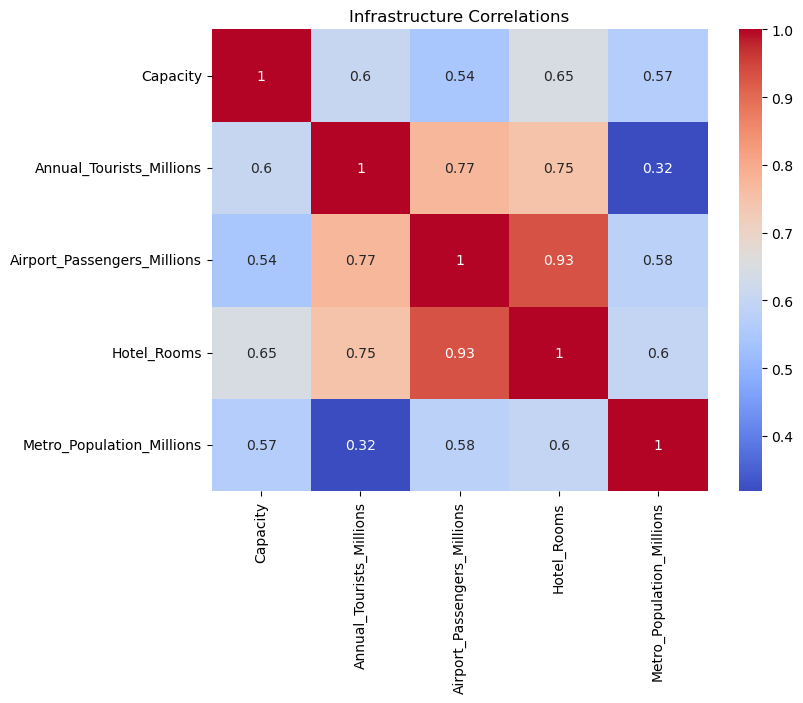

In [36]:
numeric_cols = [
    'Capacity',
    'Annual_Tourists_Millions',
    'Airport_Passengers_Millions',
    'Hotel_Rooms',
    'Metro_Population_Millions'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Infrastructure Correlations')
plt.show()

In [37]:
from sklearn.preprocessing import MinMaxScaler

cols = [
    'Annual_Tourists_Millions',
    'Airport_Passengers_Millions',
    'Hotel_Rooms',
    'Metro_Population_Millions'
]

scaler = MinMaxScaler()

df_scaled = df.copy()
df_scaled[cols] = scaler.fit_transform(df[cols])

df_scaled['Infrastructure_Score'] = (
    df_scaled[cols].mean(axis=1)
)

df_scaled.sort_values(
    'Infrastructure_Score',
    ascending=False
)[['City','Infrastructure_Score']]

,City,Infrastructure_Score
0,New York,0.975765
3,Los Angeles,0.707794
2,Atlanta,0.652283
1,Dallas,0.492838
11,Mexico City,0.475066
8,Houston,0.392949
7,Miami,0.351564
5,San Francisco Bay Area,0.350666
4,Philadelphia,0.317570
6,Seattle,0.305313


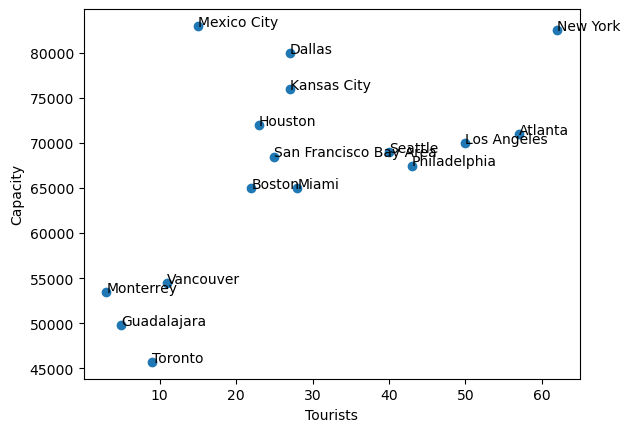

In [38]:
plt.scatter(
    df['Annual_Tourists_Millions'],
    df['Capacity']
)

for _, row in df.iterrows():
    plt.annotate(
        row['City'],
        (row['Annual_Tourists_Millions'],
         row['Capacity'])
    )

plt.xlabel('Tourists')
plt.ylabel('Capacity')
plt.show()

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = df[
    [
        'Capacity',
        'Annual_Tourists_Millions',
        'Airport_Passengers_Millions',
        'Hotel_Rooms'
    ]
]

scaler = StandardScaler()
X = scaler.fit_transform(features)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X)

D:\Softwares\Python\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



In [40]:
cluster_summary = df.groupby('Cluster')[
    [
        'Capacity',
        'Annual_Tourists_Millions',
        'Airport_Passengers_Millions',
        'Hotel_Rooms'
    ]
].mean()

print(cluster_summary)

         Capacity  Annual_Tourists_Millions  Airport_Passengers_Millions  \
Cluster                                                                    
0         70750.0                    27.875                       45.375   
1         50875.0                     7.000                       26.750   
2         75875.0                    49.000                      104.250   

         Hotel_Rooms  
Cluster               
0            53125.0  
1            28750.0  
2           105000.0  


In [41]:
df[['Stadium','City','Cluster']]

,Stadium,City,Cluster
0,MetLife Stadium,New York,2
1,AT&T Stadium,Dallas,2
2,Mercedes-Benz Stadium,Atlanta,2
3,SoFi Stadium,Los Angeles,2
4,Lincoln Financial Field,Philadelphia,0
5,Levi's Stadium,San Francisco Bay Area,0
6,Lumen Field,Seattle,0
7,Hard Rock Stadium,Miami,0
8,NRG Stadium,Houston,0
9,Arrowhead Stadium,Kansas City,0


Cluster 2
↓
Global Commercial Hubs

Cluster 0
↓
Balanced Infrastructure + Football Markets

Cluster 1
↓
Regional / Football-Culture Cities

In [42]:
df['Capacity_per_Million'] = (
    df['Capacity']
    /
    df['Metro_Population_Millions']
)

In [43]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(
    df[
        [
            'Capacity',
            'Annual_Tourists_Millions',
            'Airport_Passengers_Millions',
            'Hotel_Rooms',
            'Metro_Population_Millions'
        ]
    ]
)

pca = PCA(n_components=2)

components = pca.fit_transform(X)

df['PC1'] = components[:,0]
df['PC2'] = components[:,1]

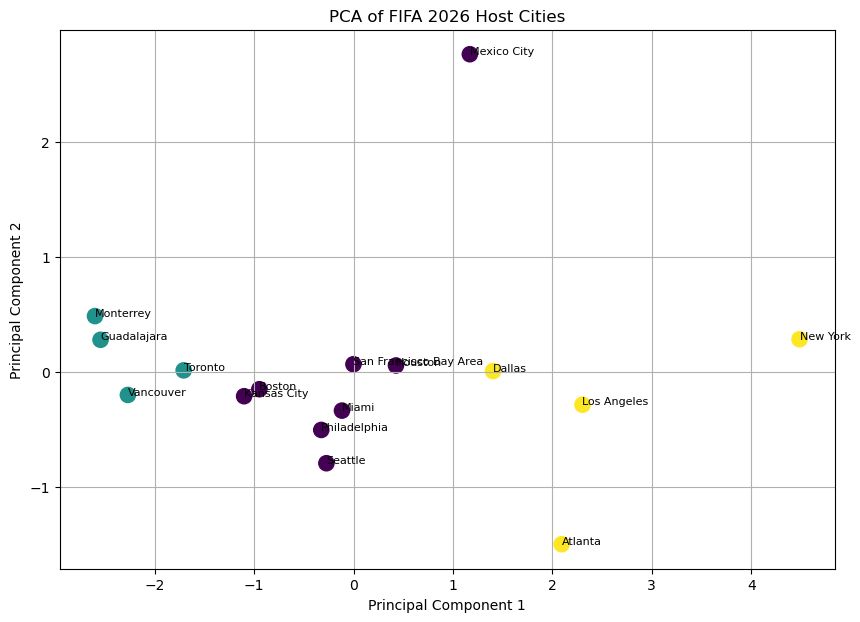

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

plt.scatter(
    df['PC1'],
    df['PC2'],
    c=df['Cluster'],
    cmap='viridis',
    s=120
)

for _, row in df.iterrows():
    plt.annotate(
        row['City'],
        (row['PC1'], row['PC2']),
        fontsize=8
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of FIFA 2026 Host Cities')
plt.grid(True)

plt.show()